In [1]:
import time
start_notebook = time.time()

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("FlightDelayPredictionBigData") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.network.timeout", "800s") \
    .config("spark.executor.heartbeatInterval", "100s") \
    .config("spark.rdd.compress", "true") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "2g") \
    .getOrCreate()

HDFS_PATH = "hdfs://localhost:9000/data/"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

from pyspark.sql import functions as F
from pyspark.sql.functions import col, when, lpad, concat, lit, substring

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression, DecisionTreeClassifier, GBTClassifier,
    RandomForestClassifier, LinearSVC, NaiveBayes
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

In [3]:
airlines = spark.read.csv(HDFS_PATH + "airlines.csv", header=True, inferSchema=True, sep=",")
airports  = spark.read.csv(HDFS_PATH + "airports.csv",  header=True, inferSchema=True, sep=",")
flights   = spark.read.csv(HDFS_PATH + "flights.csv",   header=True, inferSchema=True, sep=",")
print("Data loaded successfully")

Data loaded successfully


In [4]:
TIME_COLS = ['SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME']
for tcol in TIME_COLS:
    time_string_col = lpad(
        when(col(tcol) == 2400, 0).otherwise(col(tcol)).cast("int").cast("string"), 4, "0"
    )
    flights = flights.withColumn(
        tcol, concat(substring(time_string_col, 1, 2), lit(":"), substring(time_string_col, 3, 2))
    )

flights = flights.filter(F.col("CANCELLED") == 0)
flights = flights.withColumn("label", F.when(F.col("ARRIVAL_DELAY") > 15, 1).otherwise(0))
flights = flights.withColumn(
    "DEP_TIME_MINUTES",
    F.split(F.col("DEPARTURE_TIME"), ":")[0].cast("int") * 60 +
    F.split(F.col("DEPARTURE_TIME"), ":")[1].cast("int")
)
print("Data preprocessing completed")

Data preprocessing completed


In [5]:
print("Caching flights dataset...")
flights.cache()
flights.count()

train_data, test_data = flights.randomSplit([0.8, 0.2], seed=42)
train_data.persist()
test_data.persist()

total_count   = train_data.count()
delay_count   = train_data.filter(F.col("label") == 1.0).count()
on_time_count = total_count - delay_count
weight_for_delay  = total_count / (2.0 * delay_count)
weight_for_ontime = total_count / (2.0 * on_time_count)

train_data_weighted = train_data.withColumn(
    "classWeight",
    F.when(F.col("label") == 1.0, weight_for_delay).otherwise(weight_for_ontime)
)
train_data_weighted.persist()

print(f"Train size: {total_count:,}")
print(f"Test size:  {test_data.count():,}")
print("Cache & Persist completed.")

Caching flights dataset...
Train size: 4,584,224
Test size:  1,144,971
Cache & Persist completed.


In [6]:
categorical_cols = ['MONTH', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
numeric_cols     = ['DEP_TIME_MINUTES', 'DISTANCE', 'DEPARTURE_DELAY']

prep_stages = []
for c in categorical_cols:
    prep_stages.append(StringIndexer(inputCol=c, outputCol=c+'_Index', handleInvalid='keep'))
    prep_stages.append(OneHotEncoder(inputCol=c+'_Index', outputCol=c+'_Vec'))

assembler_inputs = [c+'_Vec' for c in categorical_cols] + numeric_cols
prep_stages.append(VectorAssembler(inputCols=assembler_inputs, outputCol='features'))

prep_model = Pipeline(stages=prep_stages).fit(train_data_weighted)

train_transformed = prep_model.transform(train_data_weighted).persist()
test_transformed  = prep_model.transform(test_data).persist()

evaluator = BinaryClassificationEvaluator(
    labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC'
)

print("Shared preprocessing pipeline fitted. train_transformed and test_transformed ready.")

Shared preprocessing pipeline fitted. train_transformed and test_transformed ready.


In [7]:
def evaluate_model(predictions, model_name):
    print(f"\n{'='*70}")
    print(f"RESULTS: {model_name}")
    print(f"{'='*70}")
    roc_auc   = BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC').evaluate(predictions)
    accuracy  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy').evaluate(predictions)
    precision = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision').evaluate(predictions)
    recall    = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall').evaluate(predictions)
    f1        = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1').evaluate(predictions)
    print(f"1. ROC-AUC Score: {roc_auc:.4f}")
    print(f"2. Accuracy:      {accuracy:.4f}")
    print(f"3. Precision:     {precision:.4f}")
    print(f"4. Recall:        {recall:.4f}")
    print(f"5. F1-Score:      {f1:.4f}")
    y = predictions.select('label', 'prediction').toPandas()
    print(f"\n{'='*70}\nCLASSIFICATION REPORT\n{'='*70}")
    print(classification_report(y['label'], y['prediction'], target_names=['On Time', 'Delay']))
    return {'auc': roc_auc, 'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}


def extract_feature_importance(model, predictions, importance_type='coefficient'):
    features_metadata = predictions.schema['features'].metadata['ml_attr']['attrs']
    all_features = []
    for _, attr_list in features_metadata.items():
        for attr in attr_list:
            all_features.append((attr['idx'], attr['name']))
    all_features.sort(key=lambda x: x[0])
    feature_names = [x[1] for x in all_features]
    if importance_type == 'coefficient':
        vals = model.coefficients.toArray()
        df = pd.DataFrame({'Feature_Name': feature_names, 'Coefficient': vals,
                           'Absolute_Importance': np.abs(vals)})
        return df.sort_values('Absolute_Importance', ascending=False).reset_index(drop=True)
    else:
        vals = model.featureImportances.toArray()
        df = pd.DataFrame({'Feature_Name': feature_names, 'Importance': vals})
        return df.sort_values('Importance', ascending=False).reset_index(drop=True)


print("Helper functions defined.")

Helper functions defined.


In [8]:
print("\n" + "="*70)
print("TRAINING: LOGISTIC REGRESSION")
print("="*70)

lr = LogisticRegression(featuresCol='features', labelCol='label', weightCol='classWeight')

model_lr = lr.fit(train_transformed)
predictions_lr = model_lr.transform(test_transformed)

results_lr_base = evaluate_model(predictions_lr, 'Logistic Regression')
model_lr.write().overwrite().save('model/flight_logistic_model')

feature_imp_lr = extract_feature_importance(model_lr, predictions_lr, 'coefficient')
print("\nTOP 15 FEATURES (LR):")
print(feature_imp_lr.head(15))


TRAINING: LOGISTIC REGRESSION

RESULTS: Logistic Regression
1. ROC-AUC Score: 0.9357
2. Accuracy:      0.9073
3. Precision:     0.9154
4. Recall:        0.9073
5. F1-Score:      0.9102

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     On Time       0.96      0.92      0.94    940667
       Delay       0.70      0.83      0.76    204304

    accuracy                           0.91   1144971
   macro avg       0.83      0.88      0.85   1144971
weighted avg       0.92      0.91      0.91   1144971


TOP 15 FEATURES (LR):
                     Feature_Name  Coefficient  Absolute_Importance
0   DESTINATION_AIRPORT_Vec_13459   -10.560567            10.560567
1   DESTINATION_AIRPORT_Vec_11503   -10.085016            10.085016
2   DESTINATION_AIRPORT_Vec_13541    -9.866501             9.866501
3   DESTINATION_AIRPORT_Vec_12016    -9.082964             9.082964
4   DESTINATION_AIRPORT_Vec_13127    -9.074145             9.074145
5        ORIGIN_AIRPORT_Vec_10268

In [9]:
print("\n" + "="*70)
print("TRAINING: DECISION TREE")
print("="*70)

dt       = DecisionTreeClassifier(featuresCol='features', labelCol='label',
                                   weightCol='classWeight', maxDepth=5, maxBins=32,
                                   impurity='gini', seed=42)
model_dt = dt.fit(train_transformed)
predictions_dt = model_dt.transform(test_transformed)

results_dt = evaluate_model(predictions_dt, 'Decision Tree')
model_dt.write().overwrite().save('model/flight_decision_tree_model')

feature_imp_dt = extract_feature_importance(model_dt, predictions_dt, 'featureImportances')
print("\nTOP 15 FEATURES (DT):")
print(feature_imp_dt.head(15))


TRAINING: DECISION TREE

RESULTS: Decision Tree
1. ROC-AUC Score: 0.7853
2. Accuracy:      0.9154
3. Precision:     0.9191
4. Recall:        0.9154
5. F1-Score:      0.9169

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     On Time       0.96      0.94      0.95    940667
       Delay       0.74      0.81      0.77    204304

    accuracy                           0.92   1144971
   macro avg       0.85      0.87      0.86   1144971
weighted avg       0.92      0.92      0.92   1144971


TOP 15 FEATURES (DT):
                     Feature_Name  Importance
0                 DEPARTURE_DELAY    0.998995
1                  AIRLINE_Vec_WN    0.000580
2                  AIRLINE_Vec_UA    0.000332
3     DESTINATION_AIRPORT_Vec_LAX    0.000093
4   DESTINATION_AIRPORT_Vec_12264    0.000000
5     DESTINATION_AIRPORT_Vec_TVC    0.000000
6   DESTINATION_AIRPORT_Vec_14683    0.000000
7     DESTINATION_AIRPORT_Vec_SBP    0.000000
8     DESTINATION_AIRPORT_Vec_LNK    0.

In [10]:
print("\n" + "="*70)
print("TRAINING: GRADIENT BOOSTING TREES")
print("="*70)

gbt_base          = GBTClassifier(featuresCol='features', labelCol='label',
                                   weightCol='classWeight', maxIter=10, maxDepth=4,
                                   stepSize=0.1, seed=42)
model_gbt_base    = gbt_base.fit(train_transformed)
predictions_gbt_base = model_gbt_base.transform(test_transformed)

results_gbt_base = evaluate_model(predictions_gbt_base, 'GBT')

feature_imp_gbt = extract_feature_importance(model_gbt_base, predictions_gbt_base, 'featureImportances')
print("\nTOP 15 FEATURES (GBT):")
print(feature_imp_gbt.head(15))


TRAINING: GRADIENT BOOSTING TREES

RESULTS: GBT
1. ROC-AUC Score: 0.9319
2. Accuracy:      0.9138
3. Precision:     0.9182
4. Recall:        0.9138
5. F1-Score:      0.9155

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     On Time       0.96      0.94      0.95    940667
       Delay       0.73      0.81      0.77    204304

    accuracy                           0.91   1144971
   macro avg       0.85      0.87      0.86   1144971
weighted avg       0.92      0.91      0.92   1144971


TOP 15 FEATURES (GBT):
                   Feature_Name  Importance
0               DEPARTURE_DELAY    0.940266
1                AIRLINE_Vec_DL    0.016920
2                      DISTANCE    0.011772
3                AIRLINE_Vec_WN    0.010114
4                AIRLINE_Vec_UA    0.009405
5   DESTINATION_AIRPORT_Vec_LAX    0.003746
6   DESTINATION_AIRPORT_Vec_ORD    0.001320
7                AIRLINE_Vec_US    0.001153
8                AIRLINE_Vec_HA    0.000983
9           

In [11]:
print("\n" + "="*70)
print("TRAINING: RANDOM FOREST")
print("="*70)

rf       = RandomForestClassifier(featuresCol='features', labelCol='label',
                                   weightCol='classWeight', numTrees=100,
                                   maxDepth=5, seed=42)
model_rf = rf.fit(train_transformed)
predictions_rf = model_rf.transform(test_transformed)

results_rf = evaluate_model(predictions_rf, 'Random Forest')
model_rf.write().overwrite().save('model/flight_random_forest_model')

feature_imp_rf = extract_feature_importance(model_rf, predictions_rf, 'featureImportances')
print("\nTOP 15 FEATURES (RF):")
print(feature_imp_rf.head(15))


TRAINING: RANDOM FOREST

RESULTS: Random Forest
1. ROC-AUC Score: 0.8899
2. Accuracy:      0.9074
3. Precision:     0.9144
4. Recall:        0.9074
5. F1-Score:      0.9100

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     On Time       0.96      0.93      0.94    940667
       Delay       0.71      0.82      0.76    204304

    accuracy                           0.91   1144971
   macro avg       0.83      0.87      0.85   1144971
weighted avg       0.91      0.91      0.91   1144971


TOP 15 FEATURES (RF):
                     Feature_Name  Importance
0                 DEPARTURE_DELAY    0.234467
1                DEP_TIME_MINUTES    0.166270
2                  AIRLINE_Vec_DL    0.082118
3                    MONTH_Vec_10    0.042950
4                     MONTH_Vec_9    0.031235
5                  AIRLINE_Vec_NK    0.030469
6                     MONTH_Vec_6    0.028437
7                     MONTH_Vec_2    0.028125
8          ORIGIN_AIRPORT_Vec_ORD    0.

In [12]:
print("\n" + "="*70)
print("TRAINING: LINEAR SVM")
print("="*70)

svm       = LinearSVC(featuresCol='features', labelCol='label',
                       weightCol='classWeight', maxIter=20, regParam=0.1)
model_svm = svm.fit(train_transformed)
predictions_svm = model_svm.transform(test_transformed)

results_svm = evaluate_model(predictions_svm, 'Linear SVM')
model_svm.write().overwrite().save('model/flight_svm_model')

feature_imp_svm = extract_feature_importance(model_svm, predictions_svm, 'coefficient')
print("\nTOP 15 FEATURES (SVM):")
print(feature_imp_svm.head(15))


TRAINING: LINEAR SVM

RESULTS: Linear SVM
1. ROC-AUC Score: 0.9243
2. Accuracy:      0.9281
3. Precision:     0.9273
4. Recall:        0.9281
5. F1-Score:      0.9232

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     On Time       0.93      0.99      0.96    940667
       Delay       0.91      0.66      0.77    204304

    accuracy                           0.93   1144971
   macro avg       0.92      0.82      0.86   1144971
weighted avg       0.93      0.93      0.92   1144971


TOP 15 FEATURES (SVM):
                     Feature_Name  Coefficient  Absolute_Importance
0        ORIGIN_AIRPORT_Vec_13964     1.169639             1.169639
1          ORIGIN_AIRPORT_Vec_GST     0.995817             0.995817
2          ORIGIN_AIRPORT_Vec_AKN     0.871014             0.871014
3          ORIGIN_AIRPORT_Vec_ADK     0.870025             0.870025
4   DESTINATION_AIRPORT_Vec_14711     0.827264             0.827264
5     DESTINATION_AIRPORT_Vec_GUM     0.811293    

In [13]:
print("\n" + "="*70)
print("TRAINING: NAIVE BAYES")
print("="*70)

nb_preprocessing_stages = []
for col_name in categorical_cols:
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_Index", handleInvalid="keep")
    nb_preprocessing_stages.append(indexer)

nb_assembler_inputs = [col_name + "_Index" for col_name in categorical_cols] + ["DISTANCE", "DEPARTURE_DELAY"]
nb_assembler = VectorAssembler(inputCols=nb_assembler_inputs, outputCol="features")
nb_preprocessing_stages.append(nb_assembler)

nb_preprocessing_pipeline = Pipeline(stages=nb_preprocessing_stages)
nb_preprocessing_model = nb_preprocessing_pipeline.fit(train_data)  # Fit on unweighted data

train_transformed_nb = nb_preprocessing_model.transform(train_data)
train_transformed_nb.cache()
train_transformed_nb.count()

test_transformed_nb = nb_preprocessing_model.transform(test_data)
test_transformed_nb.cache()
test_transformed_nb.count()

nb = NaiveBayes(
    featuresCol="features", labelCol="label",
    smoothing=1.0, modelType="gaussian"
)
model_nb = nb.fit(train_transformed_nb)
predictions_nb = model_nb.transform(test_transformed_nb)

results_nb = evaluate_model(predictions_nb, "Naive Bayes")
model_nb.write().overwrite().save("model/flight_naive_bayes_model")


TRAINING: NAIVE BAYES

RESULTS: Naive Bayes
1. ROC-AUC Score: 0.5283
2. Accuracy:      0.9330
3. Precision:     0.9312
4. Recall:        0.9330
5. F1-Score:      0.9300

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     On Time       0.94      0.98      0.96    940667
       Delay       0.89      0.71      0.79    204304

    accuracy                           0.93   1144971
   macro avg       0.92      0.85      0.88   1144971
weighted avg       0.93      0.93      0.93   1144971



In [14]:
print("\nCleaning up cached data...")
flights.unpersist()
train_data.unpersist()
test_data.unpersist()
train_data_weighted.unpersist()
train_transformed.unpersist()
test_transformed.unpersist()
train_transformed_nb.unpersist()
test_transformed_nb.unpersist()
print("✓ All cached data unpersisted.")

total_time = time.time() - start_notebook
print(f"\n{'='*70}")
print(f"TỔNG THỜI GIAN CHẠY: {total_time:.2f} giây ({total_time/60:.1f} phút)")
print(f"{'='*70}")


Cleaning up cached data...
✓ All cached data unpersisted.

TỔNG THỜI GIAN CHẠY: 689.73 giây (11.5 phút)


In [16]:
comparison_df = pd.DataFrame({
    'Model':     ['Logistic Regression','Decision Tree','GBT','Random Forest','Linear SVM','Naive Bayes'],
    'ROC-AUC':   [results_lr_base['auc'],  results_dt['auc'],  results_gbt_base['auc'],
                  results_rf['auc'],  results_svm['auc'], results_nb['auc']],
    'Accuracy':  [results_lr_base['accuracy'],  results_dt['accuracy'],  results_gbt_base['accuracy'],
                  results_rf['accuracy'],  results_svm['accuracy'], results_nb['accuracy']],
    'Precision': [results_lr_base['precision'], results_dt['precision'], results_gbt_base['precision'],
                  results_rf['precision'], results_svm['precision'],results_nb['precision']],
    'Recall':    [results_lr_base['recall'],    results_dt['recall'],    results_gbt_base['recall'],
                  results_rf['recall'],    results_svm['recall'],   results_nb['recall']],
    'F1-Score':  [results_lr_base['f1'],  results_dt['f1'],  results_gbt_base['f1'],
                  results_rf['f1'],  results_svm['f1'], results_nb['f1']]
})

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.round(4).to_string(index=False))


MODEL COMPARISON SUMMARY
              Model  ROC-AUC  Accuracy  Precision  Recall  F1-Score
Logistic Regression   0.9357    0.9073     0.9154  0.9073    0.9102
      Decision Tree   0.7853    0.9154     0.9191  0.9154    0.9169
                GBT   0.9319    0.9138     0.9182  0.9138    0.9155
      Random Forest   0.8899    0.9074     0.9144  0.9074    0.9100
         Linear SVM   0.9243    0.9281     0.9273  0.9281    0.9232
        Naive Bayes   0.5283    0.9330     0.9312  0.9330    0.9300


In [17]:
lr_tune = LogisticRegression(featuresCol='features', labelCol='label', weightCol='classWeight')
pipeline_lr = Pipeline(stages=[lr_tune])

param_grid_lr = ParamGridBuilder() \
    .addGrid(lr_tune.maxIter,         [20, 50]) \
    .addGrid(lr_tune.regParam,        [0.01, 0.1, 0.5]) \
    .addGrid(lr_tune.elasticNetParam, [0.0, 0.5]) \
    .build()

train_sample_lr, _ = train_transformed.randomSplit([0.1, 0.9], seed=42)

cv_lr = CrossValidator(estimator=pipeline_lr, estimatorParamMaps=param_grid_lr,
                       evaluator=evaluator, numFolds=3, seed=42)
cv_model_lr = cv_lr.fit(train_sample_lr)
best_lr = cv_model_lr.bestModel.stages[-1]

print(f"Best maxIter:        {best_lr.getMaxIter()}")
print(f"Best regParam:       {best_lr.getRegParam()}")
print(f"Best elasticNetParam:{best_lr.getElasticNetParam()}")

lr_final = LogisticRegression(
    featuresCol='features', labelCol='label', weightCol='classWeight',
    maxIter=best_lr.getMaxIter(),
    regParam=best_lr.getRegParam(),
    elasticNetParam=best_lr.getElasticNetParam()
)
model_lr = lr_final.fit(train_transformed)
predictions_lr = model_lr.transform(test_transformed)

results_lr = evaluate_model(predictions_lr, 'Logistic Regression (Tuned)')
model_lr.write().overwrite().save('model/flight_logistic_model')

print(f"\nBaseline  ROC-AUC: {results_lr_base['auc']:.4f} | F1: {results_lr_base['f1']:.4f}")
print(f"Tuned     ROC-AUC: {results_lr['auc']:.4f} | F1: {results_lr['f1']:.4f}")

Best maxIter:        20
Best regParam:       0.01
Best elasticNetParam:0.5

RESULTS: Logistic Regression (Tuned)
1. ROC-AUC Score: 0.9298
2. Accuracy:      0.9217
3. Precision:     0.9226
4. Recall:        0.9217
5. F1-Score:      0.9222

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     On Time       0.96      0.95      0.95    940667
       Delay       0.77      0.79      0.78    204304

    accuracy                           0.92   1144971
   macro avg       0.86      0.87      0.87   1144971
weighted avg       0.92      0.92      0.92   1144971


Baseline  ROC-AUC: 0.9357 | F1: 0.9102
Tuned     ROC-AUC: 0.9298 | F1: 0.9222


In [18]:
gbt_tune      = GBTClassifier(featuresCol='features', labelCol='label',
                               weightCol='classWeight', seed=42)
pipeline_gbt  = Pipeline(stages=[gbt_tune])

param_grid_gbt = ParamGridBuilder() \
    .addGrid(gbt_tune.maxIter,  [10, 20]) \
    .addGrid(gbt_tune.maxDepth, [4, 6]) \
    .build()

train_sample_gbt, _ = train_transformed.randomSplit([0.1, 0.9], seed=42)

cv_gbt       = CrossValidator(estimator=pipeline_gbt, estimatorParamMaps=param_grid_gbt,
                               evaluator=evaluator, numFolds=3, seed=42)
cv_model_gbt = cv_gbt.fit(train_sample_gbt)
best_gbt     = cv_model_gbt.bestModel.stages[-1]

print(f"Best maxIter : {best_gbt.getMaxIter()}")
print(f"Best maxDepth: {best_gbt.getMaxDepth()}")

gbt_final       = GBTClassifier(featuresCol='features', labelCol='label',
                                  weightCol='classWeight', stepSize=0.1, seed=42,
                                  maxIter=best_gbt.getMaxIter(),
                                  maxDepth=best_gbt.getMaxDepth())
model_gbt       = gbt_final.fit(train_transformed)
predictions_gbt = model_gbt.transform(test_transformed)

results_gbt = evaluate_model(predictions_gbt, 'GBT (Tuned)')
model_gbt.write().overwrite().save('model/flight_gbt_model')

print(f"\nBaseline ROC-AUC: {results_gbt_base['auc']:.4f} | F1: {results_gbt_base['f1']:.4f}")
print(f"Tuned    ROC-AUC: {results_gbt['auc']:.4f} | F1: {results_gbt['f1']:.4f}")

Best maxIter : 20
Best maxDepth: 6

RESULTS: GBT (Tuned)
1. ROC-AUC Score: 0.9352
2. Accuracy:      0.9114
3. Precision:     0.9173
4. Recall:        0.9114
5. F1-Score:      0.9136

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     On Time       0.96      0.93      0.95    940667
       Delay       0.72      0.82      0.77    204304

    accuracy                           0.91   1144971
   macro avg       0.84      0.88      0.86   1144971
weighted avg       0.92      0.91      0.91   1144971


Baseline ROC-AUC: 0.9319 | F1: 0.9155
Tuned    ROC-AUC: 0.9352 | F1: 0.9136


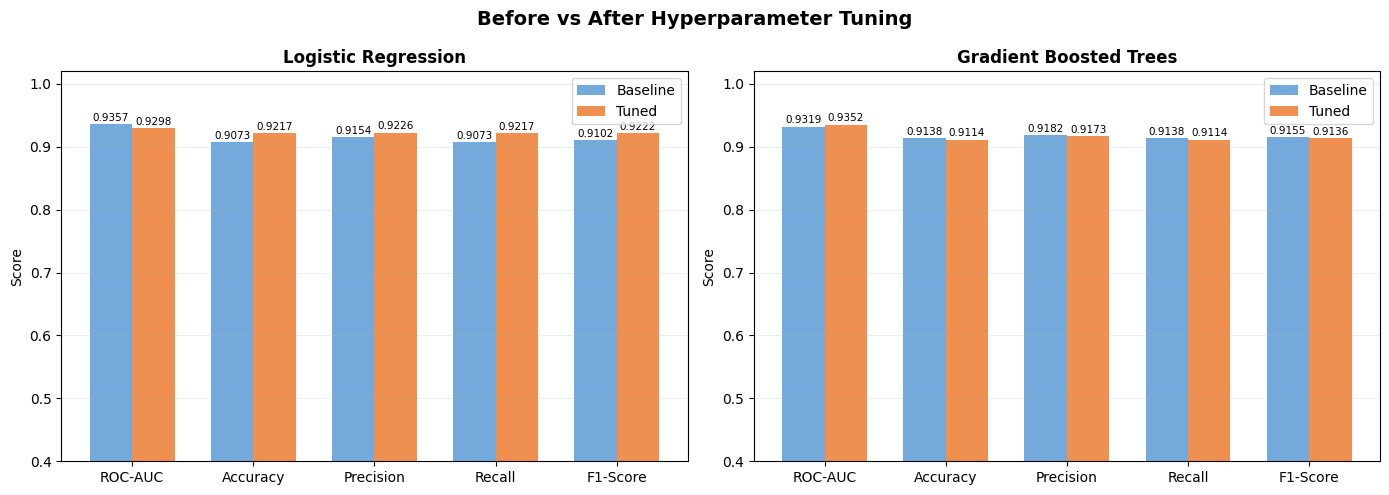

In [19]:
metrics     = ['ROC-AUC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
keys        = ['auc', 'accuracy', 'precision', 'recall', 'f1']

lr_before   = [results_lr_base[k] for k in keys]
lr_after    = [results_lr[k]      for k in keys]
gbt_before  = [results_gbt_base[k] for k in keys]
gbt_after   = [results_gbt[k]      for k in keys]

x     = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Before vs After Hyperparameter Tuning', fontsize=14, fontweight='bold')

# ── LR chart ──
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, lr_before, width, label='Baseline', color='#5B9BD5', alpha=0.85)
bars2 = ax1.bar(x + width/2, lr_after,  width, label='Tuned',    color='#ED7D31', alpha=0.85)
ax1.set_title('Logistic Regression', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0.4, 1.02)
ax1.set_ylabel('Score')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)

# ── GBT chart ──
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, gbt_before, width, label='Baseline', color='#5B9BD5', alpha=0.85)
bars4 = ax2.bar(x + width/2, gbt_after,  width, label='Tuned',    color='#ED7D31', alpha=0.85)
ax2.set_title('Gradient Boosted Trees', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics)
ax2.set_ylim(0.4, 1.02)
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)
for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()